

# **A2.1 LDA y árboles de decisión**



 De acuerdo con el INEGI, en 2024 29.6% de la población nacional (38.5 millones de personas) se encontraba en situación de pobreza multidimensional, mientras que 7 millones vivían en pobreza extrema. Estas cifras reflejan desigualdades estructurales que atraviesan comunidades enteras y condicionan su futuro. [1]

La base de datos empleada en este estudio proviene de la integración de fuentes oficiales, con variables socioeconómicas y de bienestar recopiladas del portal estatal del [INEGI](https://www.inegi.org.mx/app/estatal/). [2]

Se trata de la misma base de datos utilizada en el trabajo previo **“La deserción escolar: análisis de sus determinantes socioeconómicos”**, correspondiente al periodo 2020–2022.

 Para la presente actividad se emplea la versión ya depurada del dataset, es decir, con el proceso de tratamiento y preparación de datos previamente realizado y utilizado en proyectos anteriores.

Teniendo como objetivo el adaptar el análisis de la pobreza a un escenario de clasificación binaria, evaluando la calidad de dos enfoques: **Linear Discriminant Analysis (LDA) y árboles de decisión** . Aplicando ambos modelos sobre el mismo conjunto de datos y estableciendo la variable *Pobreza* como clase objetivo con el resto de las variables como predictoras.










### ***1. Introducción del problema***


En el presente análisis, la variable de salida seleccionada es `Pobreza`, que representa el porcentaje de población en situación de pobreza multidimensional en cada entidad federativa.

De acuerdo con el INEGI, en 2024  el 29.6% de la población nacional se encontraba en situación de pobreza multidimensional, mientras que estados como Chiapas (66.0%), Guerrero (58.1%) y Oaxaca (51.6%) presentaron los niveles más altos. En contraste, entidades como Baja California (9.9%) o Nuevo León (10.6%) mostraron niveles bajos. Estos resultados permiten establecer que porcentajes superiores al 40% pueden considerarse “alta pobreza”, mientras que valores menores a ese umbral corresponden a “baja pobreza”. Así, esta selección nos permitirá llevar a cabo la simplificación del problema y la distinción entre las distintas condiciones socioeconómicas. [3]


#### ***1.2 Importación de datos***

Para dar inicio al análisis técnico, es necesario cargar la base de datos correspondiente **`Desercion_depurado.csv`**, previamente recopilada del portal de datos.

Una vez que el archivo se encuentra en la carpeta de trabajo, se importará la librería `pandas`, la cual permite la manipulación y análisis de datos estructurados. Posteriormente, mediante el uso de la función `read_cvs()`, se realiza la lectura del archivo, almacenándose en un objeto `data`, el cual contendrá información de las 32 entidades federativas.

Igualmente, es necesario revisar el contenido del presente archivo. Mediante la función `print()` se aplicará la función `head()` en la variable `data`, desplegando por default las primeras cinco filas de datos.

In [ ]:
import pandas as pd
data =pd.read_csv('Desercion_depurado.csv')
print(data.head())

               Entidad  Pobreza  Desocupacion  Serv_salud  Red_apoyo  \
0       Aguascalientes     23.7      0.841393    0.828106  -0.358725   
1      Baja California     13.4     -0.666383    0.651229   1.044288   
2  Baja California Sur     13.3     -0.127892    1.543654   2.166698   
3             Campeche     45.1     -0.450987    0.152757   0.687157   
4             Coahuila     18.2      1.272187    1.350697   0.304518   

   Desercion  Sat_vida  Homicidios_log  Pm25_log  Analfabeta_log  \
0  -0.839486  0.662298       -1.264057 -0.239899       -1.419899   
1   0.190994  1.220023        1.502265  1.114353       -0.519580   
2   1.043805  0.662298       -0.662096 -2.202820       -1.886686   
3   0.581866 -1.010876       -0.566276  0.703408       -0.800024   
4   0.759535  1.777748       -1.388012 -0.477491       -0.836208   

   No_electricidad_log  Viv_habitadas_log  
0            -1.853407          -1.095109  
1             0.483087           0.422794  
2            -0.862994    

A continuación, se describen las variables incluidas en el análisis: [3]


| Variable          | Descripción                                                                 |
|-------------------|-----------------------------------------------------------------------------|
| **Entidad**       | Nombre oficial de la entidad federativa.                                    |
| **Pobreza**       | Porcentaje de la población en situación de pobreza.                         |
| **Pm25**          | Concentración promedio de partículas PM2.5 (µg/m³).                         |
| **Homicidios**    | Tasa de homicidios por cada 100 mil habitantes.                             |
| **Desocupacion**  | Tasa de desocupación (%).                                                   |
| **Serv_salud**    | Porcentaje de población con acceso a servicios de salud.                    |
| **Red_apoyo**     | Porcentaje de población que reporta contar con redes de apoyo.              |
| **Analfabeta_15** | Número de personas mayores de 15 años que no saben leer ni escribir.        |
| **No_electricidad** | Número de viviendas sin acceso a electricidad.                           |
| **Viv_habitadas** | Número total de viviendas habitadas en la entidad.                          |
| **Desercion**     | Porcentaje de deserción escolar.                                            |
| **Sat_vida**      | Nivel promedio de satisfacción con la vida.                                 |


Las variables expresadas en porcentaje representan proporciones relativas al total de viviendas de cada entidad federativa, lo cual permite comparabilidad territorial independientemente del tamaño poblacional.





#### ***1.3 Binarización de la variable de salida "Pobreza"***

Del dataset previamente depurado se mantuvo la variable Pobreza en su escala original, con el propósito de aplicar el criterio oficial del 40% para la clasificación. Por lo tanto, para llevar a cabo el modelo de regresión logística, se binarizó la variable Pobreza de la siguiente manera:


* 1 = Alta pobreza (entidades con valores ≥ 40%)
* 0 = Baja pobreza (entidades con valores < 40%)

Para ello se creará una nueva variable binaria llamada `Pobreza_binaria`, a partir de la original `Pobreza`. Donde, se muestran las primeras filas `Entidad`, `Pobreza` con `.head()` y la nueva variable binarizada, para verificar que la transformación se realizó correctamente.


In [ ]:
import numpy as np

data['Pobreza_binaria'] = np.where(data['Pobreza'] >= 40, 1, 0)


print(data[['Entidad', 'Pobreza', 'Pobreza_binaria']].head())

               Entidad  Pobreza  Pobreza_binaria
0       Aguascalientes     23.7                0
1      Baja California     13.4                0
2  Baja California Sur     13.3                0
3             Campeche     45.1                1
4             Coahuila     18.2                0


La nueva variable de salida correponderá a **Pobreza_binaria**, la cual clasifica a las observaciones en dos categorías: **pobreza alta o pobreza baja**; permitiendo así adaptar el problema a un escenario de clasificación.




#### ***1.4 Partición de datos***

Tras seleccionar la variable de salida, *Pobreza_binaria*, con dos clases: pobreza alta y pobreza baja. Es necesario verificar el balance entre clases en el conjunto original. De manera que, se aplicará una división entrenamiento y prueba utilizando  dos enfoques: 80/20 y 70/30. Teniendo como objetivo identificar la proporción más adecuada que nos permita mantener el balance de clases en ambos subconjuntos.

Siendo esto crucial para garantizar una evaluación justa, evitando así sesgos sobre alguna clase mayoritaria y permitiendo que las métricas de calidad utilizadas muestren de manera confiable el desempeño de ambas clases.

Para ello, se empleará la función  `train_test_split` del módulo `sklearn.model_selection`, asegurando que las variables de prueba no se usaran durante el entrenamiento, evitando así la fuga de información. Además de utilizar la función `histplot` para mostrar un gráfico representativo de las distribucines dentro del dataset.

=== División 80/20 ===
                 Original  Entrenamiento  Prueba
Pobreza_binaria                                 
0                    0.59            0.6    0.57
1                    0.41            0.4    0.43

=== División 70/30 ===
                 Original  Entrenamiento  Prueba
Pobreza_binaria                                 
0                    0.59           0.59     0.6
1                    0.41           0.41     0.4


/tmp/ipykernel_148/1673734038.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Pobreza_binaria', data=data, palette=['#1f77b4','#ff7f0e'])
/tmp/ipykernel_148/1673734038.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['0 = Pobreza baja', '1 = Pobreza alta'])


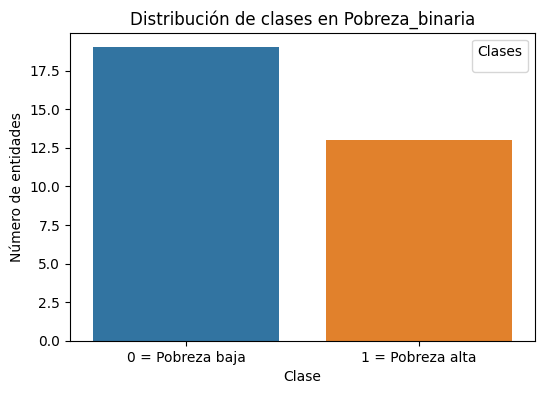

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X = data.drop(columns=['Pobreza_binaria'])

def calcular_proporciones(test_size):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    proporciones = {
        "Original": y.value_counts(normalize=True).round(2),
        "Entrenamiento": y_train.value_counts(normalize=True).round(2),
        "Prueba": y_test.value_counts(normalize=True).round(2)
    }
    return pd.DataFrame(proporciones)

print("=== División 80/20 ===")
print(calcular_proporciones(0.2))
print("\n=== División 70/30 ===")
print(calcular_proporciones(0.3))

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Pobreza_binaria', data=data, palette=['#1f77b4','#ff7f0e'])


ax.set_xticklabels(['0 = Pobreza baja', '1 = Pobreza alta'])


plt.title("Distribución de clases en Pobreza_binaria")
plt.xlabel("Clase")
plt.ylabel("Número de entidades")


handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, ['Pobreza baja', 'Pobreza alta'], title="Clases")

plt.show()

Al evaluarse las dos proporciones de división de datos: 80/20 y 70/30 es posible notar que en ambos casos se conserva el balance de clases ( aprocimadamente 59% de baja pobreza y 41% de pobreza alta). Visualizándose con el gráfico la proporción general de la variable, que aproximadamente 19 entidades están clasificadas como pobreza baja (clase 0), mientras que alrededor de 13 entidades se clasifican como pobreza alta (clase 1)

La división 80/20 ofrece más datos de entrenamiento, mientras que la división 70/30 ofrece un conjunto de prueba más amplio para la evaluación. Por lo cual se optará por utilizar la división *70/30* con el fin de contar con un mayor número de observaciones en el conjunto de prueba y verificar con mayor certeza la capacidad del modelo.


### ***2. Modelo basado en LDA***

#### ***2.1 Selección de variables***

Para llevar a cabo un modelo LDA es necesario cocntar con variables coherentes y no redundantes. Por lo cual, como primer paso, llevaremos a cabo un análisis entre las relaciones de las mismas mediante un mapa térmico de correlaciones, permitiendo identificar asociaciones fuertes que podrían generar problemas de multicolinealidad.

De manera que, se seleccionarán las variables numéricas con la función `data.[nums_vars].corr()` representándose en el mapa de calor mediante sns.heatmap. Agregando detalles al gráfico con `plt.figure` y `plt.title`, para finalmente mostrarse con `plt.show()`.


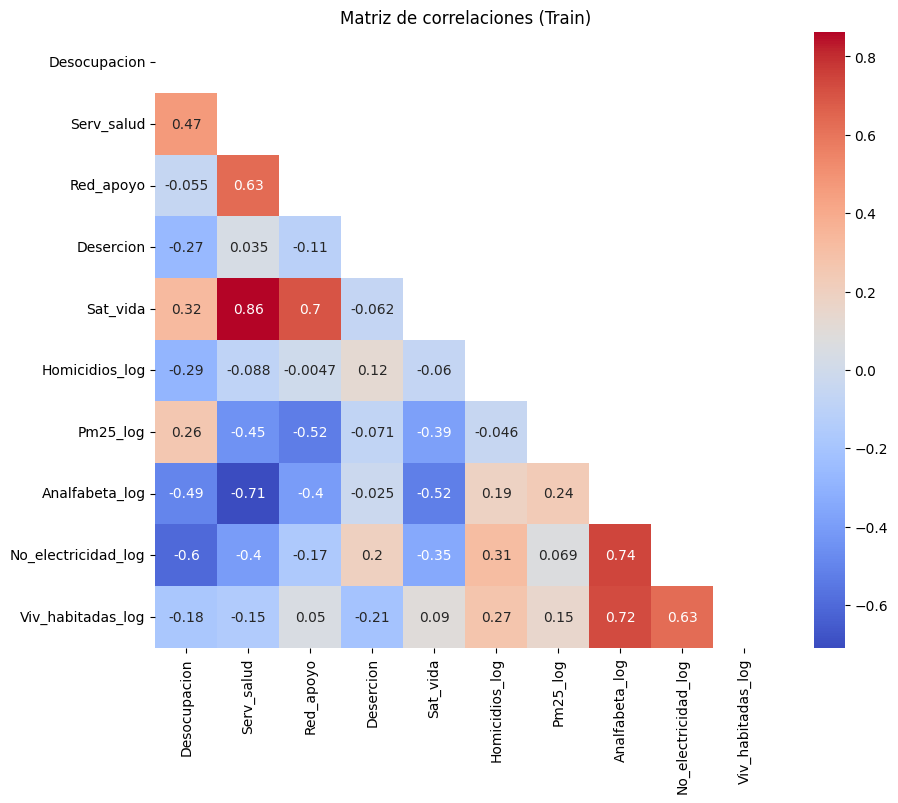

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


X = data.drop(columns=['Entidad','Pobreza_binaria','Pobreza'])
y = data['Pobreza_binaria']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


orr = X_train.corr()


mask = np.triu(np.ones_like(orr, dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(orr, annot=True, cmap='coolwarm', mask=mask)
plt.title("Matriz de correlaciones (Train)")
plt.show()

El análisis del mapa térmico muestra que satisfacción con la vida (Sat_vida) y servicios de salud (Serv_salud) presentan una correlación elevada de 0.86, lo que indica que ambas variables están midiendo dimensiones muy similares del bienestar.

Además, servicios de salud mantiene una correlación significativa con redes de apoyo (0.63), reforzando la idea de redundancia en la información que aporta.

Para evitar problemas de multicolinealidad y mejorar la estabilidad del modelo LDA, se decidió **eliminar la variable *Serv_salud***, conservando *Sat_vida y Red_apoyo* .


Una vez depuradas las variables con correlación, evaluaremos la multicolinealidad.

Utilizando el Variance Inflation Factor (VIF), el cual, se encarga de medir cla severidad de la multicolinealidad en un análisis de regresión, donde valores superiores a 10 son considerados problemátticos, ya que indican que la variable está altamente correlacionada con otras; mediante la siguiente fórmula: [4]

$VIF_i$ = $ 1/(1-R_i^2)$

Donde:

$R_i^2$ es el coeficiente de determinación no ajustado para la regresión de la i-ésima variable independiente sobre las restantes.

Utilizando  funciones de `scikit-learn` y `statsmodels`, así con `variance_inflation_factor` de `statsmodels.stats.outliers_influence` es posible calcular el VIF de cada variable.



In [ ]:
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd


X = data.drop(columns=['Entidad','Pobreza','Pobreza_binaria','Serv_salud'])
y = data['Pobreza_binaria']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data)

              Variable        VIF
0         Desocupacion   3.336285
1            Red_apoyo   3.250118
2            Desercion   1.524056
3             Sat_vida   6.547270
4       Homicidios_log   1.440609
5             Pm25_log   1.917650
6       Analfabeta_log  15.298339
7  No_electricidad_log   3.928629
8    Viv_habitadas_log  13.961127


Por su parte, con el análisis VIF realizado fue posible identificar problemas de multicolinealidad en las variables ***Analfabeta_log y Viv_habitadas_log***, contando con valores superan el umbral de 10. De manera que, para garantizar la estabilidad del modelo, estas variables fueron eliminadas. El resto de las variables presentan valores aceptables, por lo que se conservaron en el modelo.


Por su parte, para asegurarnos que las variables utilizadas nos permitan la construcción de un modelo estable. Se utilizará la homogeneidad de varianzas la cual indica que las clases que estamos comparando deberían tener varianzas similares. Importante debido a que LDA asume que las dispersiones de los grupos son comparables, si alguna cuanta con una varianza muy distinta puede sesgar la clasificación. [5]

Por lo cual, se calculará el ratio de varianzas.
- Si el ratio está cerca de 1, indica que las varianzas son similares.
- Si el ratio es muy bajo (<0.5) o muy alto (>2), indica que las varianzas son muy diferentes y esa variable puede la homogeneidad.

Para ello se utilizará  `numpy` para calcular las varianzas, `pandas` para organizarlas, y el ratio como factor para decidir qué variables conservar.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


X = data[['Desocupacion','Red_apoyo','Desercion','No_electricidad_log',
          'Sat_vida','Homicidios_log','Pm25_log']]
y = data['Pobreza_binaria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


results = []
for col in X_train.columns:
    var0 = np.var(X_train[y_train==0][col], ddof=1)
    var1 = np.var(X_train[y_train==1][col], ddof=1)
    ratio = var0/var1 if var1 != 0 else np.nan
    results.append([col, var0, var1, ratio])


var_table = pd.DataFrame(results, columns=["Variable","Var(Clase 0)","Var(Clase 1)","Ratio"])
var_table = var_table.sort_values(by="Ratio")
print(var_table)

              Variable  Var(Clase 0)  Var(Clase 1)     Ratio
0         Desocupacion      0.517342      1.623206  0.318716
3  No_electricidad_log      0.659489      1.130340  0.583443
6             Pm25_log      0.623578      0.743034  0.839232
1            Red_apoyo      0.678507      0.575910  1.178146
4             Sat_vida      0.458610      0.371540  1.234347
5       Homicidios_log      1.340025      0.720523  1.859796
2            Desercion      1.618816      0.735810  2.200046


Así, el análisis demostró que las variables *Desocupación y Deserción* no cumplen con el supuesto, por lo que fueron eliminadas. El resto de las variables presentan ratios aceptables.

De manera que, las variables seleccionadas para su uso en el modelo son las siguientes:
* No_electricidad_log
* Pm25_log
* Red_apoyo
* Sat_vida
* Homicidios_log


#### ***2.2 Modelo LDA***

El Análisis Discriminante Lineal (LDA) es una técnica estadística utilizada para clasificar observaciones en diferentes grupos a partir de variables predictoras.

Cada observación se proyecta en una función discriminante lineal que sintetiza la información de las variables y maximiza la separación entre clases. Asignando a cada caso la clase con mayor probabilidad.

Utilizando `LinearDiscriminantAnalysis` entrena el modelo sobre las variables seleccionadas y proyecta las observaciones en el espacio discriminante mediante `lda.fit` y `lda.transform`.



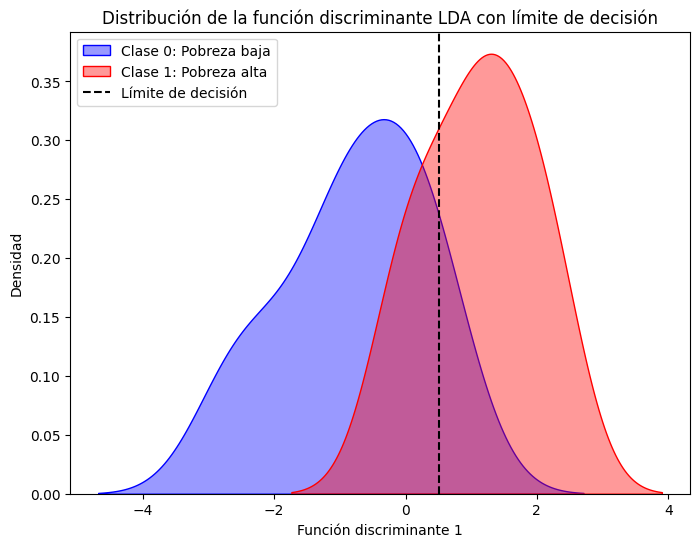

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


X = data[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log', 'No_electricidad_log']]
y = data['Pobreza_binaria']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


lda = LinearDiscriminantAnalysis()
lda_fit = lda.fit(X_train, y_train)


X_lda = lda_fit.transform(X_train)


df_lda = pd.DataFrame({
    "LDA1": X_lda[:,0],
    "Clase": y_train
})


mu0 = np.mean(df_lda[df_lda["Clase"]==0]["LDA1"])
mu1 = np.mean(df_lda[df_lda["Clase"]==1]["LDA1"])
sdT = np.std(df_lda["LDA1"])  # varianza común aproximada
prior0 = sum(y_train==0)/len(y_train)
prior1 = sum(y_train==1)/len(y_train)

boundary = (mu0**2 - mu1**2 + 2*sdT**2*(np.log(prior1) - np.log(prior0))) / (2*(mu0 - mu1))


plt.figure(figsize=(8,6))
sns.kdeplot(data=df_lda[df_lda["Clase"]==0], x="LDA1", fill=True, color="blue", alpha=0.4, label="Clase 0: Pobreza baja")
sns.kdeplot(data=df_lda[df_lda["Clase"]==1], x="LDA1", fill=True, color="red", alpha=0.4, label="Clase 1: Pobreza alta")
plt.axvline(boundary, color="black", linestyle="--", label="Límite de decisión")
plt.xlabel("Función discriminante 1")
plt.ylabel("Densidad")
plt.title("Distribución de la función discriminante LDA con límite de decisión")
plt.legend()
plt.show()

Tras realizar el modelo LDA, es posible observar la distribución de la función discriminante.

Así, la curva azul (Clase 0: Pobreza baja) cuenta con mayor concentración en la parte izquierda del eje X, indicando que las observaciones de esa clase tienen valores más bajos en la función discriminante. Mientras que, la curva roja (Clase 1: Pobreza alta) se desplaza en el lado derecho, separándose con una linea negra discontinua que marca el punto de corte con el que el modelo separa las clases.

Permitiendonos concluir que las clases se diferencían con la clase baja en valores menores y clase alta en valores mayores. De manera que, la frontera lineal propuesta se ubica en la zona donde ambas distribuciones se superponen, permitiendo una clasificación razonable en la mayoría de los casos. Sin embargo, existen observaciones en el límite que pueden ser clasificadas de forma ambigua.


#### ***2.3 Métricas de calidad***

Con el modelo listo, será posible reportar métricas de calidad relevantes, tal como la precisión, sensibilidad y f1-score, que permitirán evaluar la capacidad del modelo para identificar los casos de probreza y no pobreza.

Para ello, se utilizará la función `cross_validate` del módulo `sklearn.model_selection` para aplicar validación cruzada sobre el conjunto de entrenamiento. Empleando métricas de `sklearn.metrics` como `recall_score`, `precision_score`, que permiten calcular los indicadores de calidad relevantes.


In [ ]:
X = data[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log','No_electricidad_log']]
y = data['Pobreza_binaria']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda_fit = LinearDiscriminantAnalysis()
lda_fit.fit(X_train, y_train)


from sklearn.metrics import confusion_matrix, classification_report
yhat = lda_fit.predict(X_test)
print("Matriz de confusión:\n", confusion_matrix(y_test, yhat))
print("Reporte de clasificación:\n", classification_report(y_test, yhat))

Matriz de confusión:
 [[6 1]
 [3 0]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.67      0.86      0.75         7
           1       0.00      0.00      0.00         3

    accuracy                           0.60        10
   macro avg       0.33      0.43      0.38        10
weighted avg       0.47      0.60      0.53        10



Analizando los resultados, se observa que el modelo clasificó correctamente 6 casos de pobreza baja (Clase 0), aunque se equivocándose en 1, asignándolo erróneamente como pobreza alta. En cuanto a la clase de pobreza alta (Clase 1), no logró identificar ninguno de los 3 casos, clasificándolos todos como pobreza baja.


De esta manera, en la Clase 0 (pobreza baja), el modelo alcanzó un recall de 86%, es decir, detectó la mayoría de los casos reales de pobreza baja. Sin embargo, su precisión fue de 67%, una parte de las predicciones de pobreza baja correspondían en realidad a pobreza alta.

El F1-score de 0.75 refleja un desempeño aceptable. En la Clase 1 (pobreza alta), el modelo no logró identificar ningún caso correctamente, con valores de precisión y recall iguales a 0. Esto indica la limitación en la capacidad del modelo para reconocer esta condición.

La exactitud total fue de 60%, lo que significa que el modelo acertó en 6 de las 10 observaciones evaluadas.







A continuación se llevará a cabo la curva ROC (Receiver Operating Characteristic) mostrando un relación entre la sensibilidad (tasa de verdaderos positivos) y el 1 - especificidad (tasa de falsos positivos) para disntos umbrales de decisión.

Asimismo, el área bajo la curva (AUC) permitirá resumir en un solo valor la capacidad discriminativa del modelo: un AUC cercano a 1 indica que el modelo distingue muy bien entre las clases, mientras que un AUC cercano a 0.5 refleja un desempeño similar al azar.

Utilizando la función `roc_curve`, se calculará la relación entre sensibilidad y falsos positivos. Mediante `matplotlib`, se graficará la línea de desempeño (naranja) frente al azar (azul punteada), lo que permitirá validar visualmente la capacidad del modelo para distinguir entre pobreza y no pobreza. Obteniendo el valor AUC como indicador global de precisión.


AUC = 0.5238095238095238


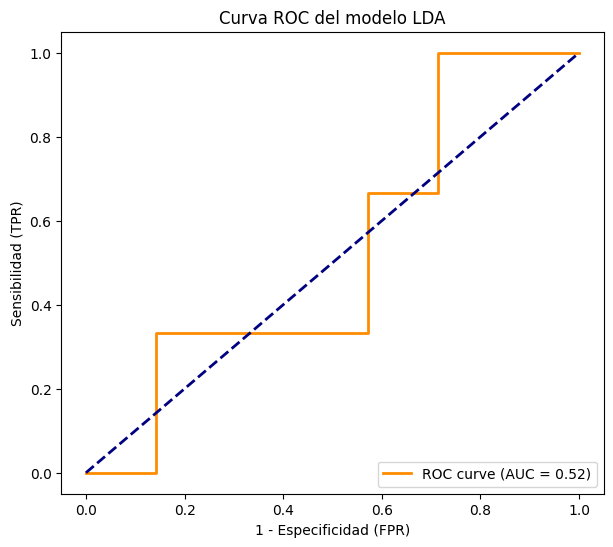

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt


X = data[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log', 'No_electricidad_log']]
y = data['Pobreza_binaria']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


lda_fit = LinearDiscriminantAnalysis()
lda_fit.fit(X_train, y_train)


p1 = lda_fit.predict_proba(X_test)[:,1]


fpr, tpr, thresholds = roc_curve(y_test, p1, pos_label=1)
roc_auc = auc(fpr, tpr)

print("AUC =", roc_auc)


plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('1 - Especificidad (FPR)')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curva ROC del modelo LDA')
plt.legend(loc="lower right")
plt.show()

El modelo presenta un desempeño limitado, con un AUC de 0.52 que indica una capacidad discriminativa limitada. La curva ROC muestra que la sensibilidad solo aumenta a costa de un número elevado de falsos positivos, evidenciando una separación no efectiva entre las clases.

### ***3. Modelo basado en árboles de decisión***

Los árboles de decisión son modelos que generan reglas claras y comprensibles para separar observaciones en distintas clases. Permitiéndote visualizar el razonamiento dtrás de la clasificación. Donde, cada nodo representa una condición sobre una variable, y cada rama muestra el camino que siguen los datos hasta llegar a una categoría final. [6]

En este caso, el árbol se construirá utilizando las variables previamente seleccionadas en el análisis exploratorio y con las distribuciones ya establecidas en la etapa anterior. Asegurando la consistencia metodológica y continuidad con el trabajo previo.

Para ello, si utilizará como variables explicativas `Red_apoyo, Homicidios_log, Pm25_log y Viv_habitadas_log`, mientras que la variable `Pobreza` se mantuvo como salida.

Utilizando `plt.figure` para definir el tamaño del gráfico, `plot_tree` para dibujar el árbol de decisión entrenado mostrando variables y reglas, y `filled=True` colorea los nodos según la clase predominante.





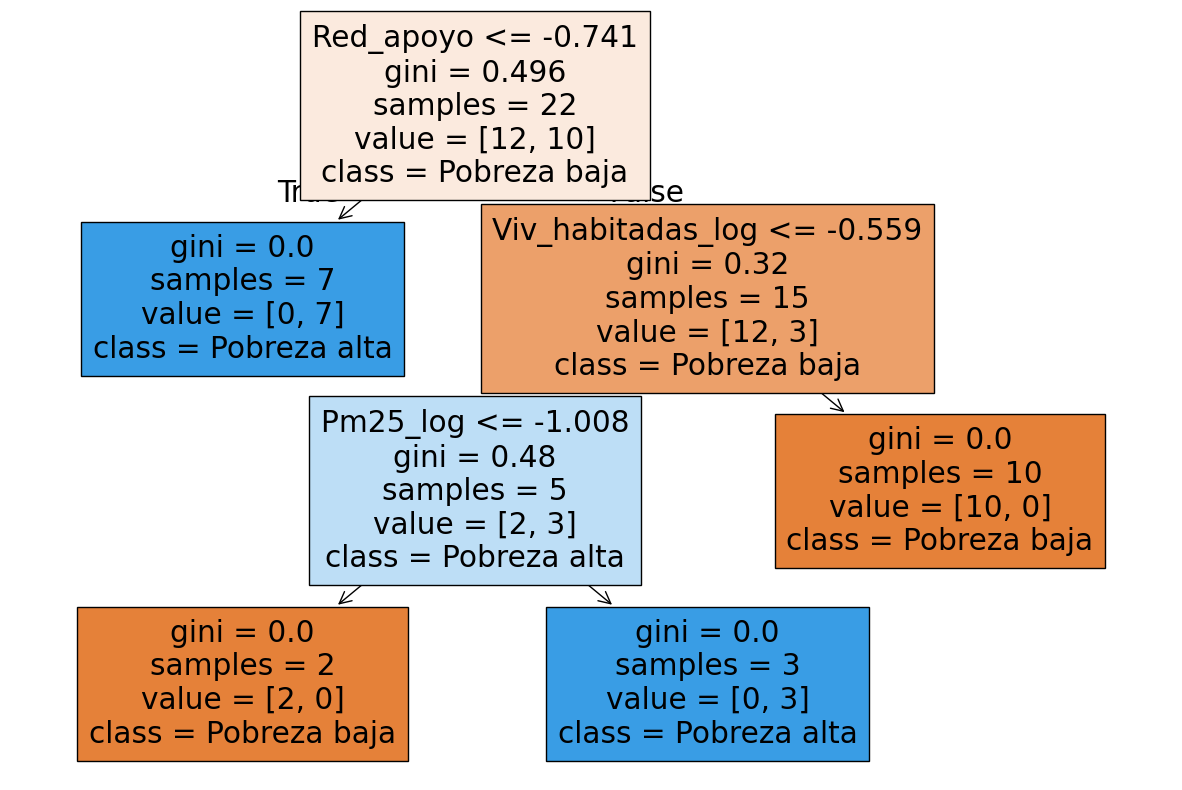

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree


X_train_sel = X_train[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log', 'No_electricidad_log']]
X_test_sel  = X_test[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log', 'No_electricidad_log']]
y_train_sel = y_train
y_test_sel  = y_test


tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_sel, y_train_sel)


plt.figure(figsize=(15,10))
plot_tree(tree,
          filled=True,
          feature_names=X_train_sel.columns,
          class_names=["Pobreza baja","Pobreza alta"])
plt.show()

Con el árbol de decisión podemos observar que comienza con la variable *Red_apoyo*, lo que indica que este factor es el más influyente en la separación inicial entre pobreza baja y alta.

Estableciendo que, si el valor de Red_apoyo es menor o igual a -0.741, el modelo clasifica directamente como pobreza alta. Sin embargo, si es mayor, se consideran otras variables como *Pm25_log y Homicidios_log*, que aparecen en los niveles siguientes.

Así,valores bajos de *Pm25_log y Homicidios_log* se asocian con pobreza baja, mientras que valores más altos a pobreza alta.

Las ramas cuentan con un Gini igual a 0, es decir, el modelo logra separar los casos sin confusión en esos nodos.


#### ***3.1 Árbol de decisión podado***

Asimismo, una vez construido el arbol inicial, el paso siguiente es el proceso de poda. Para ello, buscaremos el valor óptimo de alpha, el cual representa el parámetro de complejidad del modelo. [6]

Seleccionandose mediante un proceso de *validación cruzada*, evaluando distintos arboles con diferentes valores de alfa y escogiendo aquel que ofrece el mejor desempeño sin crecer en exceso, ya que esto podría caer en problemas de sobreajuste. [6]

Así, con nuestro alpha óptimo se reentrenará el árbol y repetirá el proceso de interpretación con un modelo más confiable.

Paara ello se utilizará `cost_complexity_pruning_path` para obtener los posibles valores de alpha, evaluándose con `cross_val_score`.


Best alpha: 0.10909090909090907


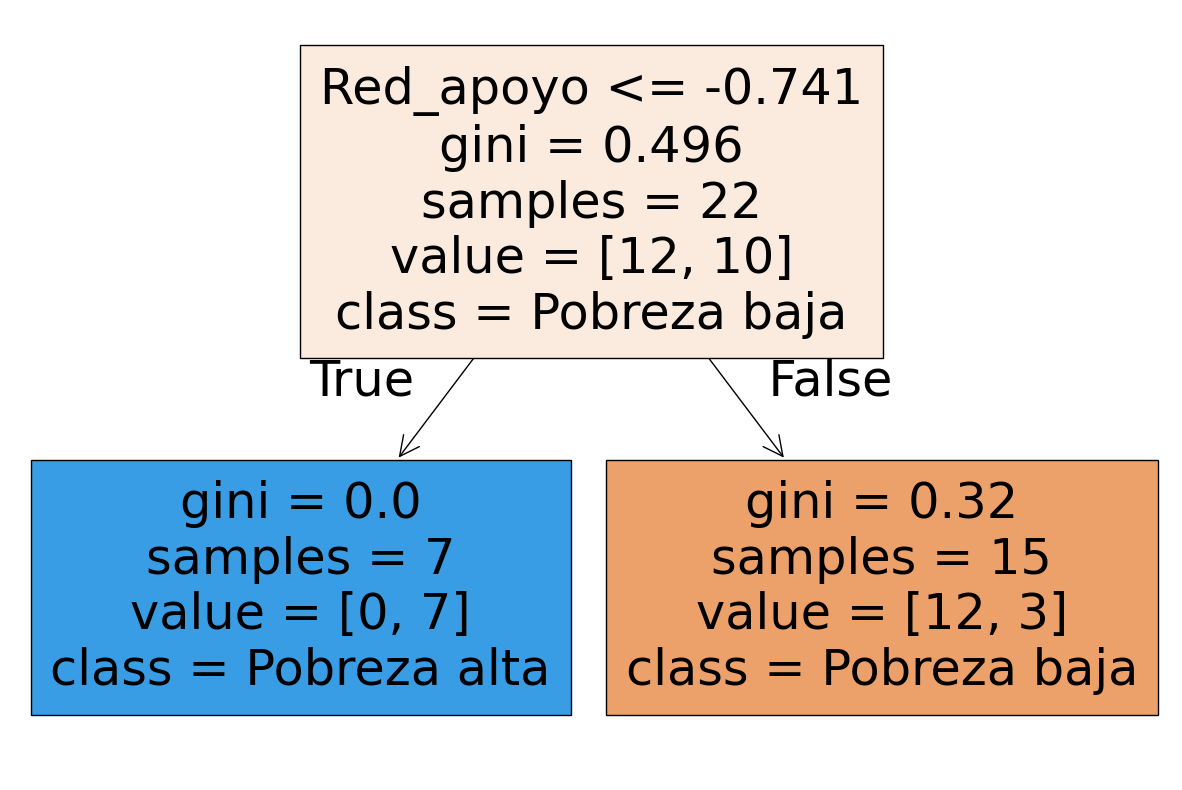

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score


X_train_sel = X_train[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log', 'No_electricidad_log']]
X_test_sel  = X_test[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log', 'No_electricidad_log']]
y_train_sel = y_train
y_test_sel  = y_test


tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_sel, y_train_sel)


path = tree.cost_complexity_pruning_path(X_train_sel, y_train_sel)
ccp_alphas = path.ccp_alphas


cv_scores = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(clf, X_train_sel, y_train_sel, cv=5)
    cv_scores.append(scores.mean())

alpha_opt = ccp_alphas[np.argmax(cv_scores)]
print("Best alpha:", alpha_opt)


tree_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_opt)
tree_pruned.fit(X_train_sel, y_train_sel)

plt.figure(figsize=(15,10))
plot_tree(tree_pruned,
          filled=True,
          feature_names=X_train_sel.columns,
          class_names=["Pobreza baja","Pobreza alta"])
plt.show()

Una vez podado, podemos observar que se mantiene a *Red_apoyo* como variable principal, mostrando su relevancia en la separación de clases de pobreza. Indicando que si su valor es menor o igual a -0.741, el modelo clasifica directamente como pobreza alta. Por otro lado, se consideraría *Pm25_log y Homicidios_lo* para la clasificación.

En busca del alpha óptimo se determinó con un valor de 0.0109, lo cual redujo la complejidad del árbol quitando las ramas menos relevantes. Donde, los nodos con el gini más cercano a cero muestran las clasificaciones más puras.


Con lo antes presentado, podemos determinar que la variable **Red_apoyo** es la más influyente en la clasificación, definiendo la separación inicial entre pobreza baja y alta.

Mientras que, **Pm25_log y Homicidios_log** a portan reglas que ajustan la clasificación, reflejando la influencia de la contaminación y la violencia en el modelo.


#### ***3.2 Métricas de calidad***

Por su parte, nuevamente se reportarán métricas de calidad relevantes, tal como la precisión, sensibilidad y f1-score, que permitirán evaluar la capacidad del modelo para identificar los casos de probreza y no pobreza. Se utilizará las mismas funciones mencionadas previamente.

In [ ]:

X = data[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log','No_electricidad_log']]
y = data['Pobreza_binaria']


from sklearn.model_selection import train_test_split
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X, y, test_size=0.3, random_state=42
)


from sklearn.tree import DecisionTreeClassifier
tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train_sel, y_train_sel)


from sklearn.metrics import confusion_matrix, classification_report
yhat = tree_pruned.predict(X_test_sel)


cm = confusion_matrix(y_test_sel, yhat)
print("Matriz de confusión:\n", cm)


rep = classification_report(y_test_sel, yhat)
print("Reporte de clasificación:\n", rep)

Matriz de confusión:
 [[5 2]
 [3 0]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.62      0.71      0.67         7
           1       0.00      0.00      0.00         3

    accuracy                           0.50        10
   macro avg       0.31      0.36      0.33        10
weighted avg       0.44      0.50      0.47        10



Con el árbol podado se observa un desempeño bajo, con un accuracy de 0.50. La clase de pobreza baja alcanza un recall de 0.71, mostrando cierta capacidad de detección aunque con errores frecuentes. Mientras que, la clase de pobreza alta no logra ser identificada en ningún caso (recall = 0.00), lo que refleja una clara limitación del modelo. Mostrando un desequilibrio marcado, donde el árbol se inclina hacia la clasificación de pobreza baja y perdiendo sensibilidad en pobreza alta.


Asimismo, se llevará a cabo nuevamente la curva ROC (Receiver Operating Characteristic) mostrando un relación entre la sensibilidad (tasa de verdaderos positivos) y el 1 - especificidad (tasa de falsos positivos) para distintos umbrales de decisión. Como también, el área bajo la curva (AUC) para resumir en un solo valor la capacidad discriminativa del modelo.

AUC = 0.35714285714285715


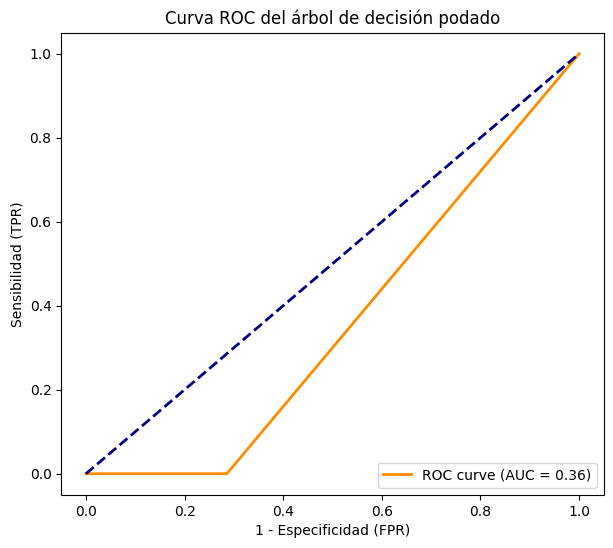

In [ ]:
# Librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

X = data[['Red_apoyo','Homicidios_log','Pm25_log','Viv_habitadas_log','No_electricidad_log']]
y = data['Pobreza_binaria']
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X, y, test_size=0.3, random_state=42
)

tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train_sel, y_train_sel)
p1_tree = tree_pruned.predict_proba(X_test_sel)[:,1]

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test_sel, p1_tree, pos_label=1)
roc_auc = auc(fpr, tpr)

print("AUC =", roc_auc)

# Visualización
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('1 - Especificidad (FPR)')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Curva ROC del árbol de decisión podado')
plt.legend(loc="lower right")
plt.show()

La curva ROC del árbol podado muestra un AUC de 0.36, indicando un desempeño inferior a la aleatoriedad. Indicando que el modelo cuenta con limitada capacidad discriminativa y no resulta adecuado para identificar la condición de pobreza alta.

### ***4. Evaluación y comparación de los modelos***

Para esta sección se presentarán los resultados obtenidos al aplicar dos modelos de clasificación: Análisis Discriminante Lineal (LDA) y Árbol de Decisión. Reportando las métricas de desempeño revisadas en clase, incluyendo accuracy, precision, recall, F1-score y el valor del AUC derivado de la curva ROC.






| Métrica              | LDA   | Árbol Decisión |
|----------------------|-------|--------------|
| Accuracy             | 0.60  | 0.50         |
| Recall Clase 0       | 0.86  | 0.71         |
| Recall Clase 1       | 0.00  | 0.00         |
| Precision Clase 0    | 0.67  | 0.62         |
| Precision Clase 1    | 0.00  | 0.00         |
| F1-score Clase 0     | 0.75  | 0.67         |
| F1-score Clase 1     | 0.00  | 0.00         |
| AUC (ROC)            | 0.52  | 0.36         |



La comparación entre LDA y el árbol de decisión muestra que, aunque el LDA cuenta con métricas algo mejores, ninguno de los modelos logra identificar casos de pobreza alta. El desempeño de manera global es bajo, con un sesgo hacia la clase mayoritaria y una capacidad discriminativa limitada como muestra el AUC.

#### ***4.1 Conclusiones finales***

Al comparar el LDA y el árbol de decisión podado, se nota que lo que muestran las gráficas coincide con lo que dicen las métricas. Las curvas ROC reflejan el mismo desempeño bajo que ya se veía en el accuracy y el recall, permitiendo verlo de forma más clara y visual.

En el caso del LDA, es posible que los supuestos del modelo (como normalidad o covarianzas iguales) no se cumplan del todo como idealmente se buscaría, sobre todo porque se trabaja con pocas observaciones.

Esto puede explicar parte de sus limitaciones en sus resultados. El árbol de decisión, por su lado, mostró un sesgo fuerte hacia la clase mayoritaria, lo que le hizo perder la capacidad de detectar pobreza alta.

Cada modelo tiene sus ventajas:
* El LDA permite ver cómo se comportan las clases y da métricas un poco mejores.
* El árbol ayuda a identificar qué variables tienen más peso en la clasificación.

Sin embargo, ambos comparten la misma limitación al no lograr clasificar correctamente la pobreza alta.

En conclusión, el LDA resulta más adecuado para esta tarea, porque ofrece un desempeño ligeramente mejor y refleja con más claridad el comportamiento de las clases. El árbol, aunque útil para explorar la importancia de las variables, no es confiable para la predicción en este caso específico.


### ***5. Referencias***

1. admin, “En México, más de 46 millones de personas viven en situación de pobreza,” Gaceta UNAM, Sep. 09, 2024. https://www.gaceta.unam.mx/en-mexico-mas-de-46-millones-de-personas-viven-en-situacion-de-pobreza/
‌
2. “Banco de Indicadores - Indicadores por entidad federativa,” www.inegi.org.mx. https://www.inegi.org.mx/app/estatal/

3. “POBREZA MULTIDIMENSIONAL,” INEGI. https://www.inegi.org.mx/contenidos/saladeprensa/boletines/2025/pm/pm2025_08.pdf
‌
4. C. Potters, “Variance Inflation Factor Definition,” Investopedia, Jun. 27, 2024. https://www.investopedia.com/terms/v/variance-inflation-factor.asp

5. “Homogeneity of Variances - (Honors Statistics) - Vocab, Definition, Explanations | Fiveable,” Fiveable.me, 2025. https://fiveable.me/key-terms/honors-statistics/homogeneity-variances
‌
6. “Modelos de árboles de decisión,” www.ibm.com. https://www.ibm.com/docs/es/spss-modeler/saas?topic=trees-decision-tree-models
‌
‌



El desarrollo de los bloques de código y la optimización de las funciones presentadas en este reporte contaron con el apoyo de herramientas de inteligencia artificial.